In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append('../src')
from db_connection import get_connection

conn = get_connection()
print("Ready!")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)


 Connected to revenue_leak_db as postgres
Ready!


C:\Users\josel\AppData\Local\Temp\ipykernel_26464\2540262614.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_26464\2540262614.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_revenue, x="total_revenue", y="category", palette="viridis", ax=ax)


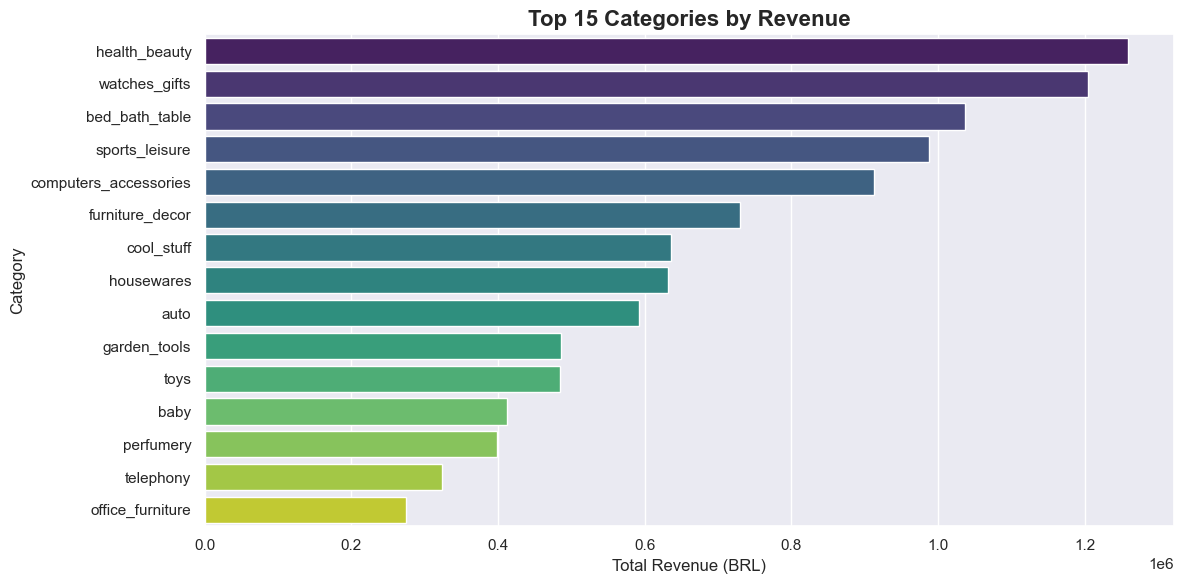

,category,total_revenue,total_orders
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689
5,furniture_decor,729762.49,6449
6,cool_stuff,635290.85,3632
7,housewares,632248.66,5884
8,auto,592720.11,3897
9,garden_tools,485256.46,3518


In [6]:
query = """
    SELECT 
        p.product_category_name_english AS category,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS total_revenue,
        COUNT(DISTINCT oi.order_id)      AS total_orders
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 15;
"""

df_revenue = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots()
sns.barplot(data=df_revenue, x="total_revenue", y="category", palette="viridis", ax=ax)
ax.set_title("Top 15 Categories by Revenue", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../visuals/revenue_by_category.png", dpi=150)
plt.show()

df_revenue

C:\Users\josel\AppData\Local\Temp\ipykernel_26464\1205946681.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_freight = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_26464\1205946681.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_freight, x="freight_pct", y="category", palette="rocket", ax=ax)


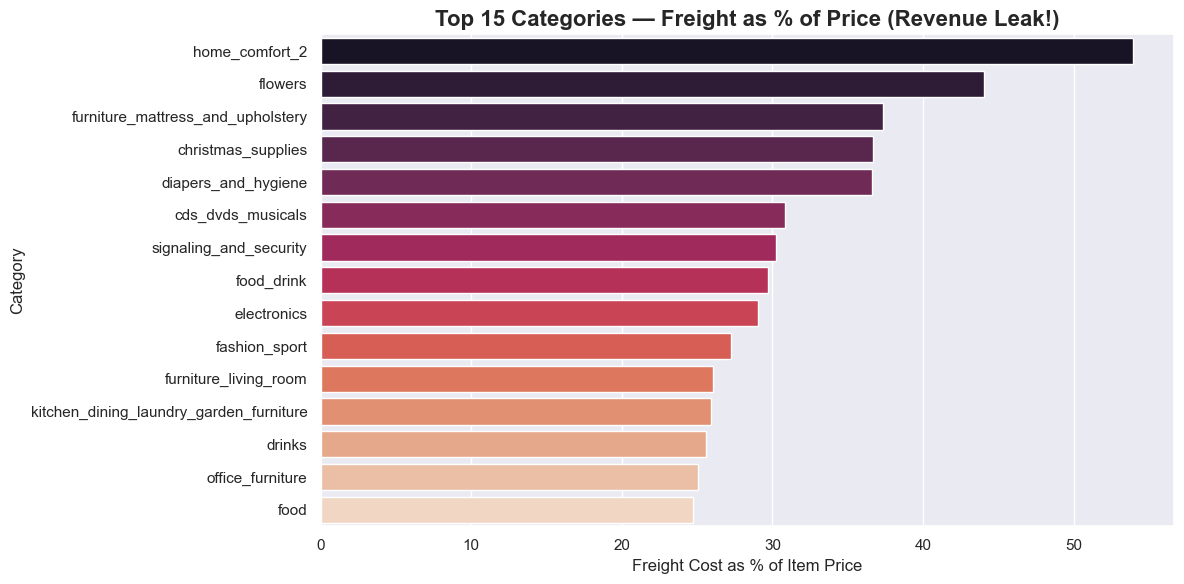

,category,avg_price,avg_freight,freight_pct
0,home_comfort_2,25.34,13.68,53.97
1,flowers,33.64,14.81,44.04
2,furniture_mattress_and_upholstery,114.95,42.91,37.33
3,christmas_supplies,57.52,21.11,36.69
4,diapers_and_hygiene,40.19,14.71,36.60
5,cds_dvds_musicals,52.14,16.07,30.82
6,signaling_and_security,108.09,32.70,30.26
7,food_drink,54.60,16.22,29.70
8,electronics,57.91,16.83,29.07
9,fashion_sport,70.65,19.27,27.28


In [7]:
query = """
    SELECT 
        p.product_category_name_english AS category,
        ROUND(AVG(oi.price)::NUMERIC, 2)         AS avg_price,
        ROUND(AVG(oi.freight_value)::NUMERIC, 2)  AS avg_freight,
        ROUND((AVG(oi.freight_value) / NULLIF(AVG(oi.price), 0) * 100)::NUMERIC, 2) AS freight_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    WHERE p.product_category_name_english != 'unknown'
    GROUP BY category
    ORDER BY freight_pct DESC
    LIMIT 15;
"""

df_freight = pd.read_sql(query, conn)

fig, ax = plt.subplots()
sns.barplot(data=df_freight, x="freight_pct", y="category", palette="rocket", ax=ax)
ax.set_title("Top 15 Categories — Freight as % of Price (Revenue Leak!)", fontsize=16, fontweight="bold")
ax.set_xlabel("Freight Cost as % of Item Price")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("../visuals/freight_vs_price.png", dpi=150)
plt.show()

df_freight

C:\Users\josel\AppData\Local\Temp\ipykernel_26464\2447940840.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_status = pd.read_sql(query, conn)


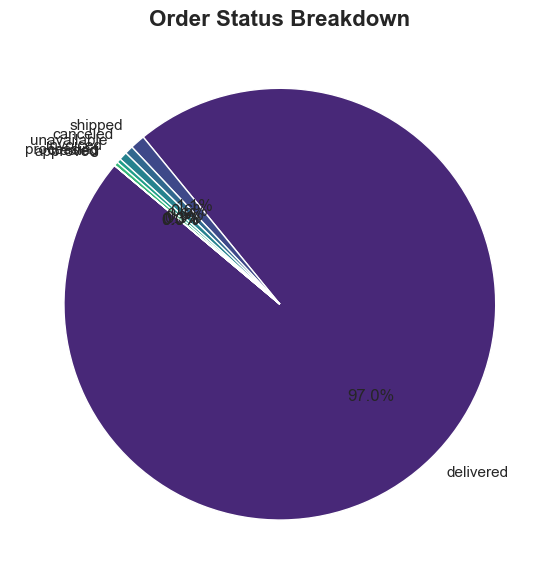

,order_status,total,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [8]:
query = """
    SELECT 
        order_status,
        COUNT(*) AS total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM orders
    GROUP BY order_status
    ORDER BY total DESC;
"""

df_status = pd.read_sql(query, conn)

fig, ax = plt.subplots()
ax.pie(
    df_status["total"],
    labels=df_status["order_status"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(df_status))
)
ax.set_title("Order Status Breakdown", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/order_status.png", dpi=150)
plt.show()

df_status

C:\Users\josel\AppData\Local\Temp\ipykernel_26464\2094743635.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trend = pd.read_sql(query, conn)


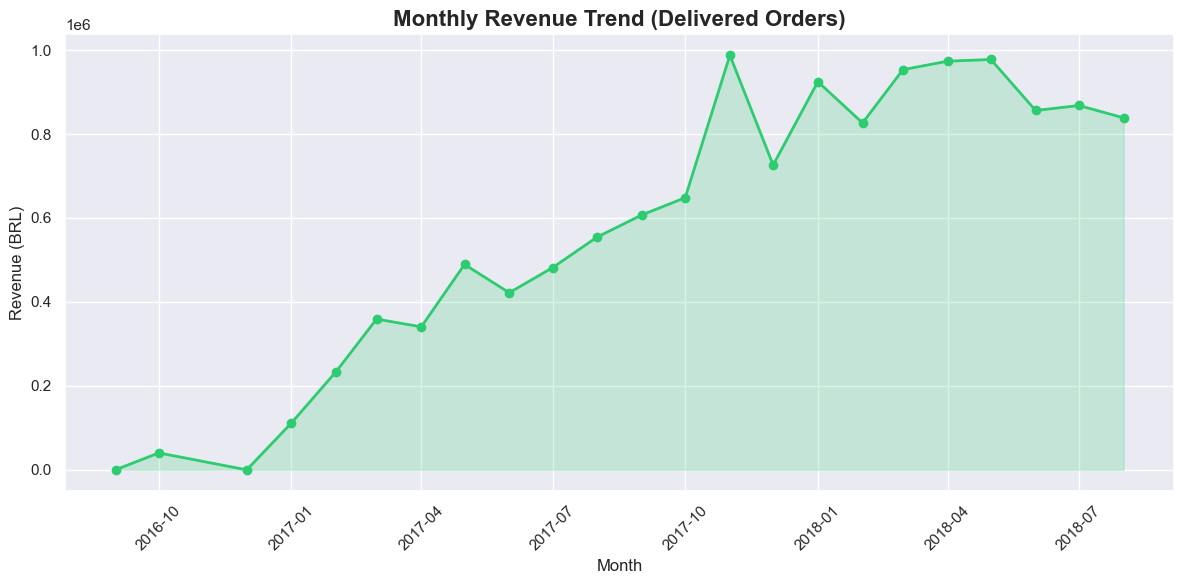

,month,monthly_revenue
0,2016-09-01,134.97
1,2016-10-01,40325.11
2,2016-12-01,10.90
3,2017-01-01,111798.36
4,2017-02-01,234223.40
5,2017-03-01,359198.85
6,2017-04-01,340669.68
7,2017-05-01,489338.25
8,2017-06-01,421923.37
9,2017-07-01,481604.52


In [9]:
query = """
    SELECT 
        DATE_TRUNC('month', o.order_purchase_timestamp::TIMESTAMP) AS month,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS monthly_revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month;
"""

df_trend = pd.read_sql(query, conn)
df_trend["month"] = pd.to_datetime(df_trend["month"])

fig, ax = plt.subplots()
ax.plot(df_trend["month"], df_trend["monthly_revenue"], marker="o", color="#2ecc71", linewidth=2)
ax.fill_between(df_trend["month"], df_trend["monthly_revenue"], alpha=0.2, color="#2ecc71")
ax.set_title("Monthly Revenue Trend (Delivered Orders)", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/monthly_trend.png", dpi=150)
plt.show()

df_trend

C:\Users\josel\AppData\Local\Temp\ipykernel_26464\785937751.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql(query, conn)
C:\Users\josel\AppData\Local\Temp\ipykernel_26464\785937751.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_customers, x="total_spent", y="customer_unique_id", palette="Blues_r", ax=ax)


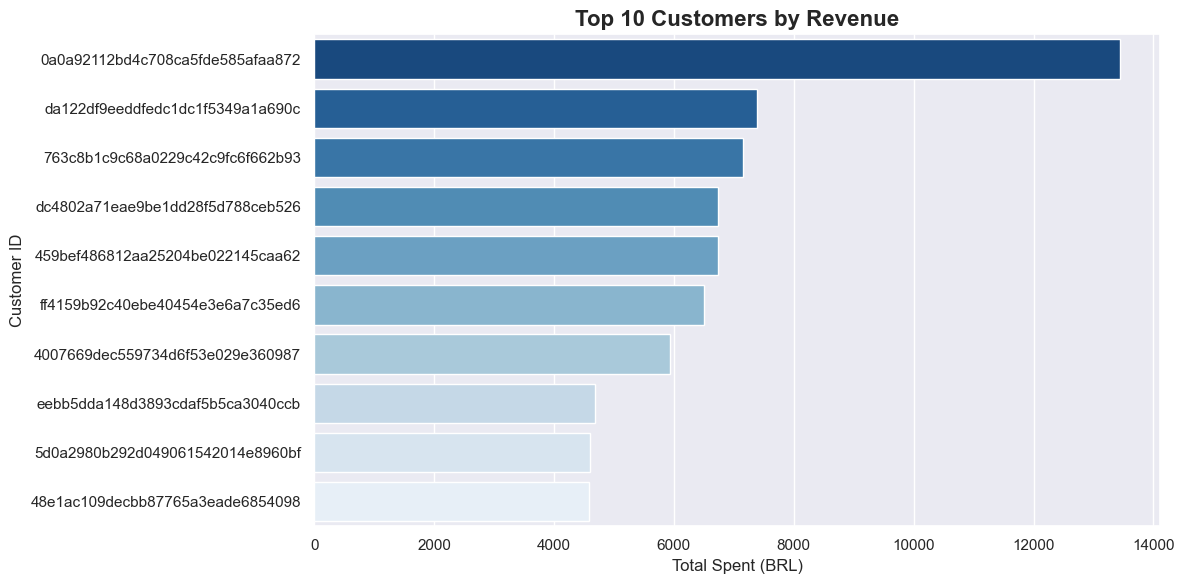

,customer_unique_id,customer_city,customer_state,total_spent,total_orders
0,0a0a92112bd4c708ca5fde585afaa872,rio de janeiro,RJ,13440.0,1
1,da122df9eeddfedc1dc1f5349a1a690c,araruama,RJ,7388.0,2
2,763c8b1c9c68a0229c42c9fc6f662b93,vila velha,ES,7160.0,1
3,dc4802a71eae9be1dd28f5d788ceb526,campo grande,MS,6735.0,1
4,459bef486812aa25204be022145caa62,vitoria,ES,6729.0,1
5,ff4159b92c40ebe40454e3e6a7c35ed6,marilia,SP,6499.0,1
6,4007669dec559734d6f53e029e360987,divinopolis,MG,5934.6,1
7,eebb5dda148d3893cdaf5b5ca3040ccb,maua,SP,4690.0,1
8,5d0a2980b292d049061542014e8960bf,goiania,GO,4599.9,1
9,48e1ac109decbb87765a3eade6854098,joao pessoa,PB,4590.0,1


In [10]:
query = """
    SELECT 
        c.customer_unique_id,
        c.customer_city,
        c.customer_state,
        ROUND(SUM(oi.price)::NUMERIC, 2) AS total_spent,
        COUNT(DISTINCT o.order_id)        AS total_orders
    FROM customers c
    JOIN orders o      ON c.customer_id  = o.customer_id
    JOIN order_items oi ON o.order_id   = oi.order_id
    GROUP BY c.customer_unique_id, c.customer_city, c.customer_state
    ORDER BY total_spent DESC
    LIMIT 10;
"""

df_customers = pd.read_sql(query, conn)

fig, ax = plt.subplots()
sns.barplot(data=df_customers, x="total_spent", y="customer_unique_id", palette="Blues_r", ax=ax)
ax.set_title("Top 10 Customers by Revenue", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Spent (BRL)")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.savefig("../visuals/top_customers.png", dpi=150)
plt.show()

df_customers

In [11]:
conn.close()
print("Connection closed.")

Connection closed.
